In [52]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PULSE_FOLDER = "AVG_PULSE"
A_RESULTS_CSV_PATH = "A_results.csv"
B_RESULTS_CSV_PATH = "B_results.csv"

AXES_ORDER = ["d1", "d2", "d3", "d4"]
B_COMPONENTS = ["Bx", "By", "Bz"]

# Field of view used for plotting- greed
EXTENT_UM = [-100, 100, -100, 100]

# Manual timing intervals chosen from the pulse trace, units s
OFF_TIME = (0.0000, 0.0500)
NEG_TIME = 0.0571  # single time point within original NEG interval
POS_TIME = 0.0627  # single time point within original POS interval

# Plot settings
CMAP_DIVERGING = "seismic"
CMAP_SIGNAL = "viridis"

In [53]:
# Expected array structure for pulse data
#   column 0       = time [s]
#   columns 1:end  = pixel voltage traces [V]

pulse_files = [
    os.path.join(PULSE_FOLDER, f"Pulse_avg_{axis}.npy")
    for axis in AXES_ORDER
]
pulse_arrays = [np.load(file) for file in pulse_files]

In [54]:
# Stack pulse data, sanity check 
time_s = pulse_arrays[0][:, 0]

for axis, arr in zip(AXES_ORDER, pulse_arrays):
    if not np.allclose(arr[:, 0], time_s):
        raise ValueError(f"Time axis mismatch in {axis}")

#   voltage_stack[channel, time, pixel]
voltage_stack = np.stack([arr[:, 1:] for arr in pulse_arrays], axis=0)

n_channels, n_timepoints, n_pixels = voltage_stack.shape
grid_size = int(np.sqrt(n_pixels))

if grid_size * grid_size != n_pixels:
    raise ValueError(f"Number of pixels is not square: {n_pixels}")

dt_s = np.median(np.diff(time_s))
frame_rate_hz = 1.0 / dt_s

print("voltage_stack shape:", voltage_stack.shape)
print("channels:", n_channels)
print("timepoints:", n_timepoints)
print("pixels:", n_pixels)
print("grid:", grid_size, "x", grid_size)
print(f"dt = {dt_s:.9f} s")
print(f"frame rate = {frame_rate_hz:.3f} Hz")

voltage_stack shape: (4, 457, 961)
channels: 4
timepoints: 457
pixels: 961
grid: 31 x 31
dt = 0.000386400 s
frame rate = 2587.992 Hz


In [55]:
#Build greed same as in experimental setup, to be used for plotting
grid = np.zeros((grid_size, grid_size), dtype=int)

for idx in range(n_pixels):
    col = idx // grid_size
    row = idx % grid_size

    if col % 2 == 0:
        # first column starts at bottom and goes up
        grid[row, grid_size - 1 - col] = idx
    else:
        # next column goes down
        grid[grid_size - 1 - row, grid_size - 1 - col] = idx

print("grid shape:", grid.shape)
print("grid pixel range:", grid.min(), "to", grid.max())

grid shape: (31, 31)
grid pixel range: 0 to 960


,phase,time_requested_s,frame_or_frames,n_frames,actual_time_s,assigned_pulse_mV,assigned_pulse_V,raw_mean_signal_V,raw_minus_OFF_V
0,OFF,"(0.0, 0.05)",0 to 129,130,0.000000 to 0.049846,0.0,0.00,-0.000002,0.000000
1,NEG,0.0571,148,1,0.057187,-10.0,-0.01,-0.000522,-0.000520
2,POS,0.0627,162,1,0.062597,10.0,0.01,0.000312,0.000314


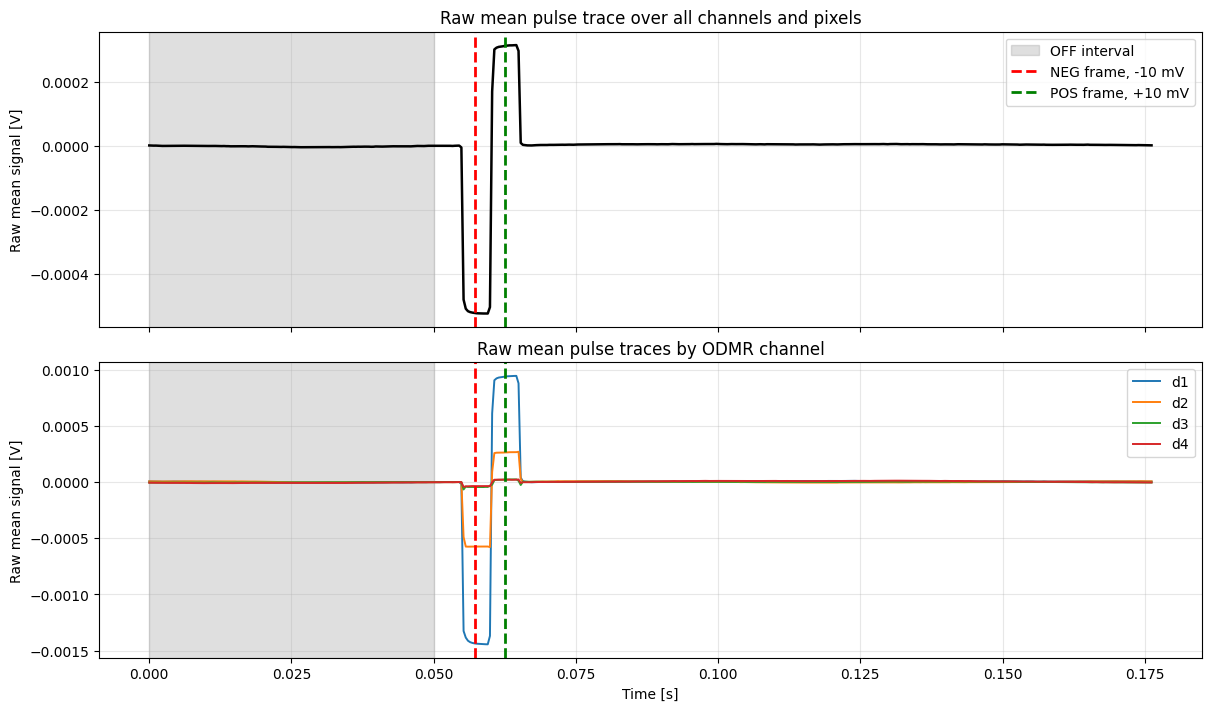

In [56]:
# Known applied pulse amplitude
PULSE_AMPLITUDE_mV = 10.0
PULSE_AMPLITUDE_V = PULSE_AMPLITUDE_mV * 1e-3

#select intervals

off_indices = np.where((time_s >= OFF_TIME[0]) & (time_s <= OFF_TIME[1]))[0]

neg_idx = np.argmin(np.abs(time_s - NEG_TIME))
pos_idx = np.argmin(np.abs(time_s - POS_TIME))

if len(off_indices) < 3:
    raise ValueError("OFF interval has too few frames. Adjust OFF_TIME.")

# ------------------------------------------------------------
# 2. Raw mean traces only for inspection


channel_mean = np.nanmean(voltage_stack, axis=2)      # [channel, time]
mean_all_channels = np.nanmean(channel_mean, axis=0)  # [time]

# Raw values from the mean trace
off_raw_mean_V = np.nanmean(mean_all_channels[off_indices])
neg_raw_V = mean_all_channels[neg_idx]
pos_raw_V = mean_all_channels[pos_idx]

# Difference relative to OFF, only printed as diagnostic
neg_minus_off_V = neg_raw_V - off_raw_mean_V
pos_minus_off_V = pos_raw_V - off_raw_mean_V

# ------------------------------------------------------------
# 3. Print selected frames and assigned applied pulse amplitude
# ------------------------------------------------------------

selection_df = pd.DataFrame([
    {
        "phase": "OFF",
        "time_requested_s": str(OFF_TIME),
        "frame_or_frames": f"{off_indices[0]} to {off_indices[-1]}",
        "n_frames": len(off_indices),
        "actual_time_s": f"{time_s[off_indices[0]]:.6f} to {time_s[off_indices[-1]]:.6f}",
        "assigned_pulse_mV": 0.0,
        "assigned_pulse_V": 0.0,
        "raw_mean_signal_V": off_raw_mean_V,
        "raw_minus_OFF_V": 0.0,
    },
    {
        "phase": "NEG",
        "time_requested_s": NEG_TIME,
        "frame_or_frames": int(neg_idx),
        "n_frames": 1,
        "actual_time_s": float(time_s[neg_idx]),
        "assigned_pulse_mV": -PULSE_AMPLITUDE_mV,
        "assigned_pulse_V": -PULSE_AMPLITUDE_V,
        "raw_mean_signal_V": neg_raw_V,
        "raw_minus_OFF_V": neg_minus_off_V,
    },
    {
        "phase": "POS",
        "time_requested_s": POS_TIME,
        "frame_or_frames": int(pos_idx),
        "n_frames": 1,
        "actual_time_s": float(time_s[pos_idx]),
        "assigned_pulse_mV": +PULSE_AMPLITUDE_mV,
        "assigned_pulse_V": +PULSE_AMPLITUDE_V,
        "raw_mean_signal_V": pos_raw_V,
        "raw_minus_OFF_V": pos_minus_off_V,
    },
])

display(selection_df)


fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, constrained_layout=True)

# Top: raw mean over all channels and pixels
axes[0].plot(time_s, mean_all_channels, color="black", lw=1.8)
axes[0].axvspan(OFF_TIME[0], OFF_TIME[1], color="gray", alpha=0.25, label="OFF interval")
axes[0].axvline(time_s[neg_idx], color="red", ls="--", lw=2, label="NEG frame, -10 mV")
axes[0].axvline(time_s[pos_idx], color="green", ls="--", lw=2, label="POS frame, +10 mV")

axes[0].set_title("Raw mean pulse trace over all channels and pixels")
axes[0].set_ylabel("Raw mean signal [V]")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bottom: raw mean by ODMR channel
for i, axis in enumerate(AXES_ORDER):
    axes[1].plot(time_s, channel_mean[i], lw=1.4, label=axis)

axes[1].axvspan(OFF_TIME[0], OFF_TIME[1], color="gray", alpha=0.25)
axes[1].axvline(time_s[neg_idx], color="red", ls="--", lw=2)
axes[1].axvline(time_s[pos_idx], color="green", ls="--", lw=2)

axes[1].set_title("Raw mean pulse traces by ODMR channel")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Raw mean signal [V]")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.show()

,axis,phase,p50_abs_dV_V,p95_abs_dV_V,max_abs_dV_V
0,d1,pos-off,0.000634,0.003022,0.004248
1,d1,neg-off,0.000757,0.005338,0.006495
2,d2,pos-off,0.000249,0.000632,0.000760
3,d2,neg-off,0.000432,0.001446,0.001798
4,d3,pos-off,0.000215,0.000479,0.000578
5,d3,neg-off,0.000223,0.000520,0.000666
6,d4,pos-off,0.000065,0.000188,0.000240
7,d4,neg-off,0.000052,0.000201,0.000280


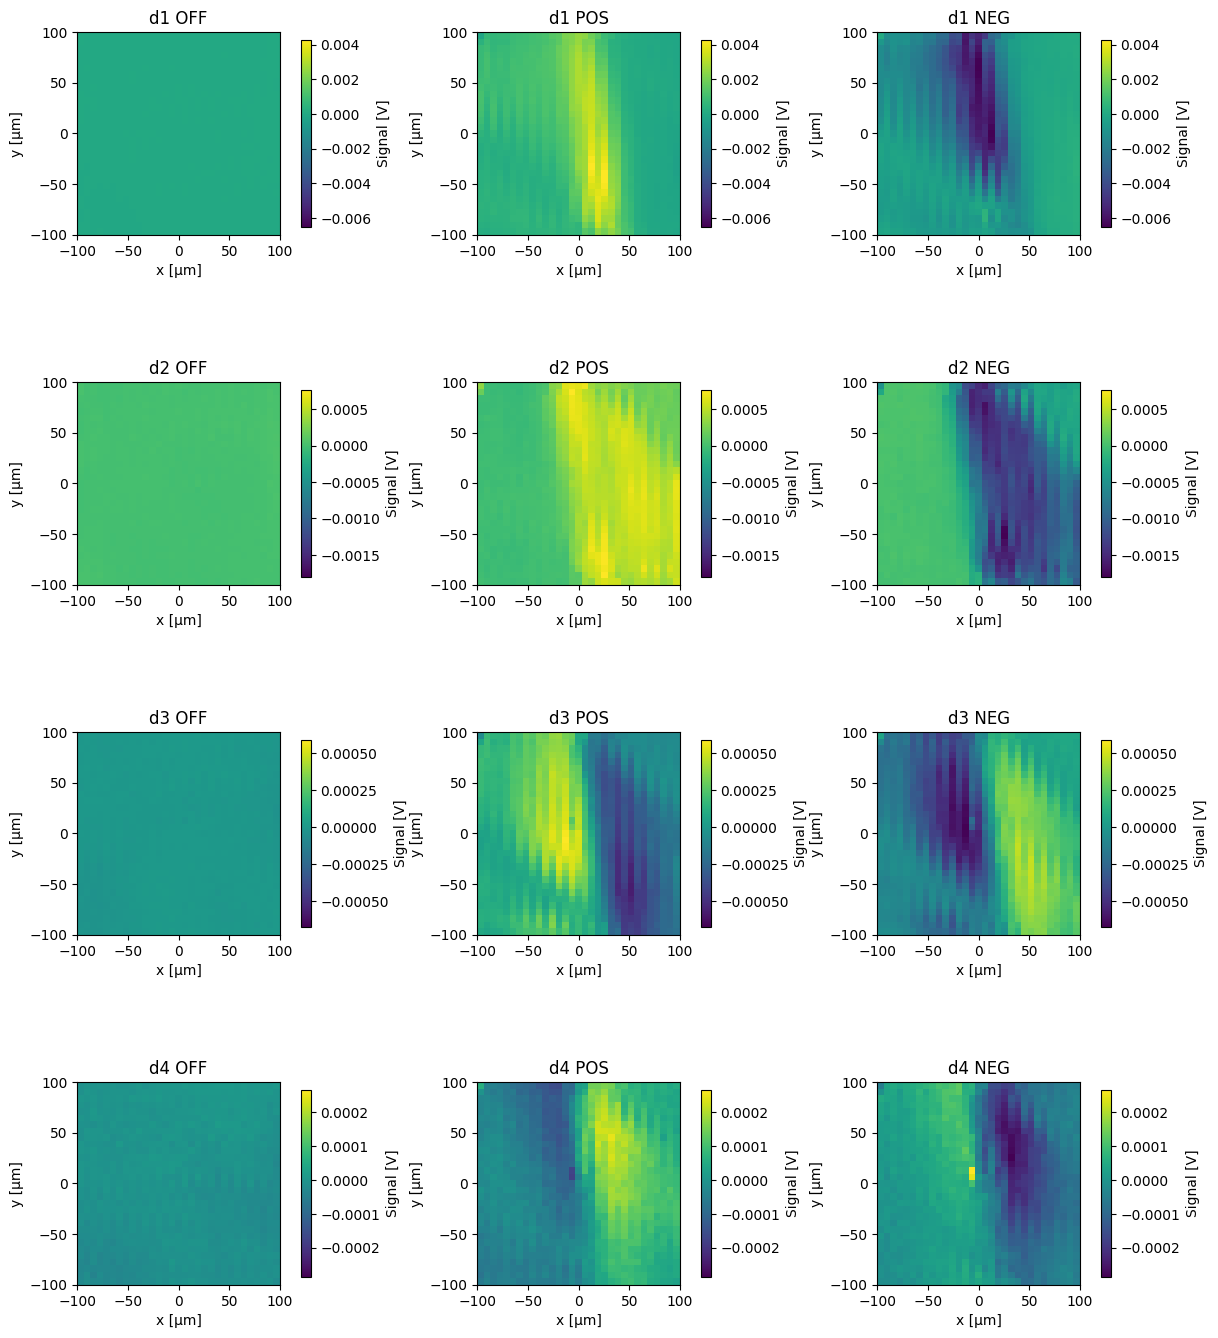

In [57]:
# ============================================================
# Compute interval-averaged voltage maps 

V_off = np.nanmean(voltage_stack[:, off_indices, :], axis=1)
V_neg = voltage_stack[:, neg_idx, :]
V_pos = voltage_stack[:, pos_idx, :]

dV_neg = V_neg - V_off
dV_pos = V_pos - V_off

dV_rows = []

for i, axis in enumerate(AXES_ORDER):
    for phase, arr in [("pos-off", dV_pos[i]), ("neg-off", dV_neg[i])]:
        dV_rows.append({
            "axis": axis,
            "phase": phase,
            "p50_abs_dV_V": np.nanpercentile(np.abs(arr), 50),
            "p95_abs_dV_V": np.nanpercentile(np.abs(arr), 95),
            "max_abs_dV_V": np.nanmax(np.abs(arr)),
        })

dV_summary_df = pd.DataFrame(dV_rows)
display(dV_summary_df)

# Plot OFF/POS/NEG voltage maps

Voff_maps = V_off[:, grid]
Vpos_maps = V_pos[:, grid]
Vneg_maps = V_neg[:, grid]

fig, axes = plt.subplots(4, 3, figsize=(12, 14), constrained_layout=True)

for i, axis in enumerate(AXES_ORDER):
    maps = [Voff_maps[i], Vpos_maps[i], Vneg_maps[i]]
    titles = [f"{axis} OFF", f"{axis} POS", f"{axis} NEG"]

    vmin = min(np.nanmin(m) for m in maps)
    vmax = max(np.nanmax(m) for m in maps)

    for j in range(3):
        im = axes[i, j].imshow(
            maps[j],
            extent=EXTENT_UM,
            origin="lower",
            aspect="equal",
            cmap=CMAP_SIGNAL,
            vmin=vmin,
            vmax=vmax,
        )

        axes[i, j].set_title(titles[j])
        axes[i, j].set_xlabel("x [µm]")
        axes[i, j].set_ylabel("y [µm]")

        cbar = plt.colorbar(im, ax=axes[i, j], fraction=0.046, pad=0.04)
        cbar.set_label("Signal [V]")

plt.show()

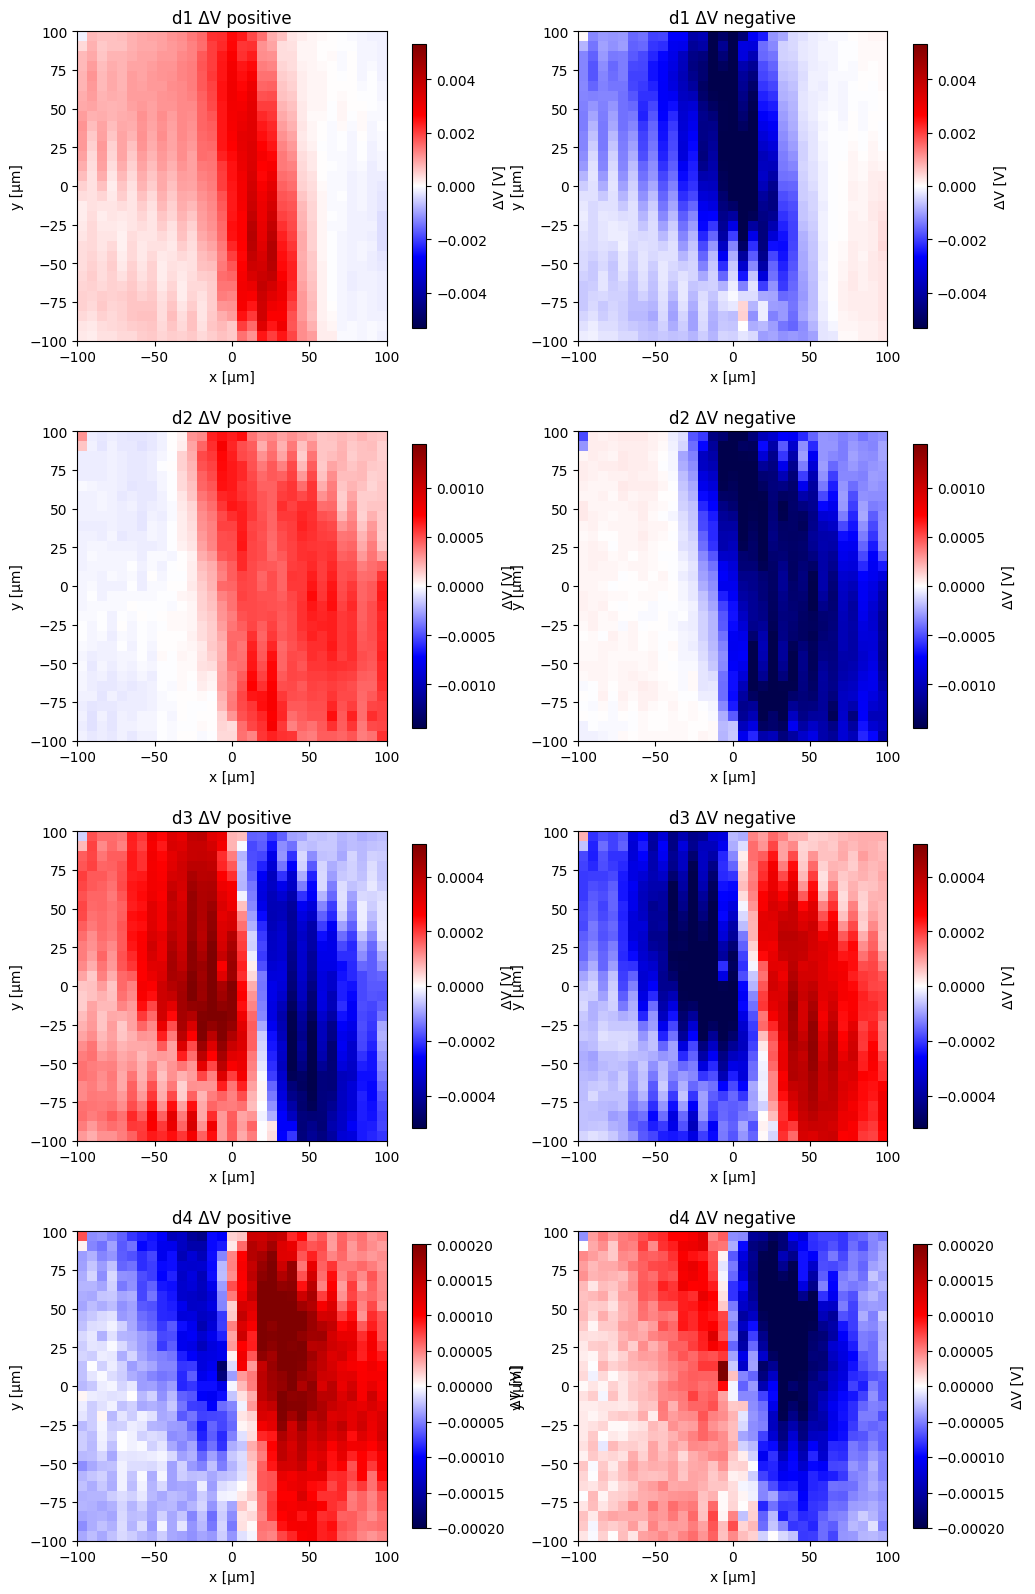

In [58]:
#voltage difference maps

dV_pos_maps = dV_pos[:, grid]
dV_neg_maps = dV_neg[:, grid]

fig, axes = plt.subplots(4, 2, figsize=(10, 16), constrained_layout=True)

for i, axis in enumerate(AXES_ORDER):
    lim = max(
        np.nanpercentile(np.abs(dV_pos_maps[i]), 95),
        np.nanpercentile(np.abs(dV_neg_maps[i]), 95),
    )

    if lim == 0 or not np.isfinite(lim):
        lim = 1.0

    im1 = axes[i, 0].imshow(
        dV_pos_maps[i],
        extent=EXTENT_UM,
        origin="lower",
        aspect="equal",
        cmap=CMAP_DIVERGING,
        vmin=-lim,
        vmax=lim,
    )
    axes[i, 0].set_title(f"{axis} ΔV positive")
    axes[i, 0].set_xlabel("x [µm]")
    axes[i, 0].set_ylabel("y [µm]")
    plt.colorbar(im1, ax=axes[i, 0], fraction=0.046, pad=0.04).set_label("ΔV [V]")

    im2 = axes[i, 1].imshow(
        dV_neg_maps[i],
        extent=EXTENT_UM,
        origin="lower",
        aspect="equal",
        cmap=CMAP_DIVERGING,
        vmin=-lim,
        vmax=lim,
    )
    axes[i, 1].set_title(f"{axis} ΔV negative")
    axes[i, 1].set_xlabel("x [µm]")
    axes[i, 1].set_ylabel("y [µm]")
    plt.colorbar(im2, ax=axes[i, 1], fraction=0.046, pad=0.04).set_label("ΔV [V]")

plt.show()

## Convert V to frequency

In [59]:
# Load ODMR slopes and A_plus from A_results.csv

A_results_df = pd.read_csv(A_RESULTS_CSV_PATH)

available_groups = set(A_results_df["group"].unique())
required_groups = {"slope", "A_plus"}

missing_groups = required_groups - available_groups

if missing_groups:
    raise ValueError(
        f"A_results.csv is missing required groups: {missing_groups}. "
        "Rerun get_A_matrix.ipynb after saving slopes and A_plus."
    )



# Extract slopes and A_plus

slopes_V_per_MHz = np.zeros(4, dtype=float)

for i, axis in enumerate(AXES_ORDER):
    rows = A_results_df[
        (A_results_df["group"] == "slope") &
        (A_results_df["row"] == axis) &
        (A_results_df["col"] == "slope")
    ]

    if len(rows) == 0:
        raise ValueError(f"Missing slope for {axis}")

    unit = str(rows["unit"].iloc[0])
    if unit != "V/MHz":
        raise ValueError(f"Unexpected slope unit for {axis}: {unit}")

    slopes_V_per_MHz[i] = float(rows["value"].iloc[0])

Aplus_nT_per_MHz = np.zeros((3, 4), dtype=float)

for i, comp in enumerate(B_COMPONENTS):
    for j, axis in enumerate(AXES_ORDER):
        rows = A_results_df[
            (A_results_df["group"] == "A_plus") &
            (A_results_df["row"] == comp) &
            (A_results_df["col"] == axis)
        ]

        if len(rows) == 0:
            raise ValueError(f"Missing A_plus entry for {comp}, {axis}")

        value = float(rows["value"].iloc[0])
        unit = str(rows["unit"].iloc[0])

        if unit == "nT/MHz":
            Aplus_nT_per_MHz[i, j] = value
        elif unit == "mT/MHz":
            Aplus_nT_per_MHz[i, j] = 1e6 * value
        else:
            raise ValueError(f"Unexpected A_plus unit for {comp}, {axis}: {unit}")

slopes_df = pd.DataFrame({
    "axis": AXES_ORDER,
    "slope_V_per_MHz": slopes_V_per_MHz,
})

Aplus_df = pd.DataFrame(
    Aplus_nT_per_MHz,
    index=B_COMPONENTS,
    columns=AXES_ORDER,
)

print("ODMR slopes loaded from A_results.csv:")
display(slopes_df)

print("A_plus loaded from A_results.csv [nT/MHz]:")
display(Aplus_df)

ODMR slopes loaded from A_results.csv:


,axis,slope_V_per_MHz
0,d1,-0.005998
1,d2,-0.006857
2,d3,-0.002656
3,d4,-0.001930


A_plus loaded from A_results.csv [nT/MHz]:


,d1,d2,d3,d4
Bx,-22954.201722,-22530.378496,-407.550787,-322.273020
By,-1968.013835,-2925.969295,-22872.279877,-22384.337267
Bz,-15620.222190,15784.051464,-13867.328231,14754.846590


In [60]:
# Convert voltage changes to frequency shifts
#   Δν [MHz] = ΔV [V] / slope [V/MHz]

deltaNu_pos_MHz = dV_pos / slopes_V_per_MHz[:, None]
deltaNu_neg_MHz = dV_neg / slopes_V_per_MHz[:, None]

deltaNu_rows = []

for i, axis in enumerate(AXES_ORDER):
    for phase, arr in [("pos-off", deltaNu_pos_MHz[i]), ("neg-off", deltaNu_neg_MHz[i])]:
        deltaNu_rows.append({
            "axis": axis,
            "phase": phase,
            "p50_abs_deltaNu_MHz": np.nanpercentile(np.abs(arr), 50),
            "p95_abs_deltaNu_MHz": np.nanpercentile(np.abs(arr), 95),
            "max_abs_deltaNu_MHz": np.nanmax(np.abs(arr)),
        })

deltaNu_summary_df = pd.DataFrame(deltaNu_rows)
display(deltaNu_summary_df)

,axis,phase,p50_abs_deltaNu_MHz,p95_abs_deltaNu_MHz,max_abs_deltaNu_MHz
0,d1,pos-off,0.105711,0.503759,0.708268
1,d1,neg-off,0.126241,0.889923,1.082920
2,d2,pos-off,0.036378,0.092168,0.110807
3,d2,neg-off,0.062977,0.210918,0.262132
4,d3,pos-off,0.080814,0.180398,0.217456
5,d3,neg-off,0.083771,0.195773,0.250899
6,d4,pos-off,0.033865,0.097631,0.124235
7,d4,neg-off,0.026981,0.103887,0.145168


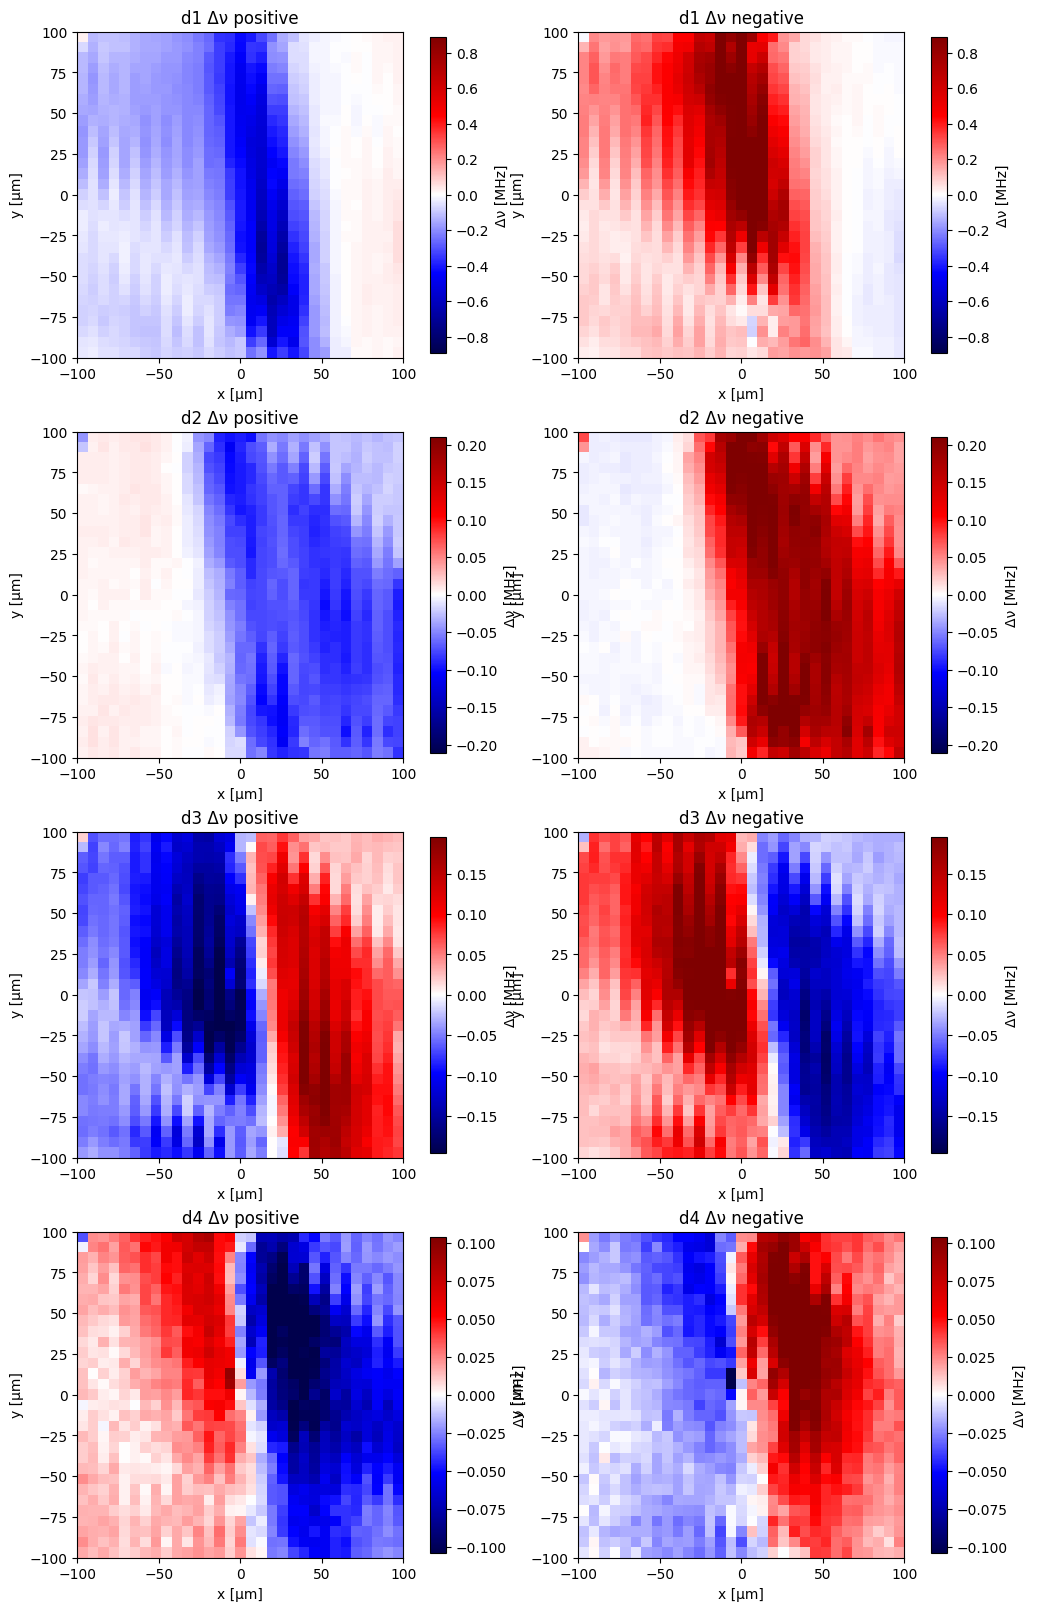

In [61]:
# Plot frequency-shift maps

deltaNu_pos_maps = deltaNu_pos_MHz[:, grid]
deltaNu_neg_maps = deltaNu_neg_MHz[:, grid]

fig, axes = plt.subplots(4, 2, figsize=(10, 16), constrained_layout=True)

for i, axis in enumerate(AXES_ORDER):
    lim = max(
        np.nanpercentile(np.abs(deltaNu_pos_maps[i]), 95),
        np.nanpercentile(np.abs(deltaNu_neg_maps[i]), 95),
    )

    if lim == 0 or not np.isfinite(lim):
        lim = 1.0

    im1 = axes[i, 0].imshow(
        deltaNu_pos_maps[i],
        extent=EXTENT_UM,
        origin="lower",
        aspect="equal",
        cmap=CMAP_DIVERGING,
        vmin=-lim,
        vmax=lim,
    )
    axes[i, 0].set_title(f"{axis} Δν positive")
    axes[i, 0].set_xlabel("x [µm]")
    axes[i, 0].set_ylabel("y [µm]")
    plt.colorbar(im1, ax=axes[i, 0], fraction=0.046, pad=0.04).set_label("Δν [MHz]")

    im2 = axes[i, 1].imshow(
        deltaNu_neg_maps[i],
        extent=EXTENT_UM,
        origin="lower",
        aspect="equal",
        cmap=CMAP_DIVERGING,
        vmin=-lim,
        vmax=lim,
    )
    axes[i, 1].set_title(f"{axis} Δν negative")
    axes[i, 1].set_xlabel("x [µm]")
    axes[i, 1].set_ylabel("y [µm]")
    plt.colorbar(im2, ax=axes[i, 1], fraction=0.046, pad=0.04).set_label("Δν [MHz]")

plt.show()

plt.show()


# 3. Apply A_plus and reconstruct magnetic field

In [62]:
# Formula:
#   B [nT] = A_plus [nT/MHz] @ Δν [MHz]

B_pos_nT = Aplus_nT_per_MHz @ deltaNu_pos_MHz
B_neg_nT = Aplus_nT_per_MHz @ deltaNu_neg_MHz

B_rows = []

for i, comp in enumerate(B_COMPONENTS):
    for phase, arr in [("pos-off", B_pos_nT[i]), ("neg-off", B_neg_nT[i])]:
        B_rows.append({
            "component": comp,
            "phase": phase,
            "p50_abs_B_nT": np.nanpercentile(np.abs(arr), 50),
            "p95_abs_B_nT": np.nanpercentile(np.abs(arr), 95),
            "max_abs_B_nT": np.nanmax(np.abs(arr)),
        })

B_summary_df = pd.DataFrame(B_rows)
display(B_summary_df)

,component,phase,p50_abs_B_nT,p95_abs_B_nT,max_abs_B_nT
0,Bx,pos-off,2799.869174,13433.715457,18447.345218
1,Bx,neg-off,4646.179905,24199.039109,29468.220758
2,By,pos-off,1247.251361,3673.775926,5336.438792
3,By,neg-off,1358.373536,5308.921674,7075.753446
4,Bz,pos-off,3363.541767,7395.124460,10327.205851
5,Bz,neg-off,4096.016982,13584.200569,15961.823775


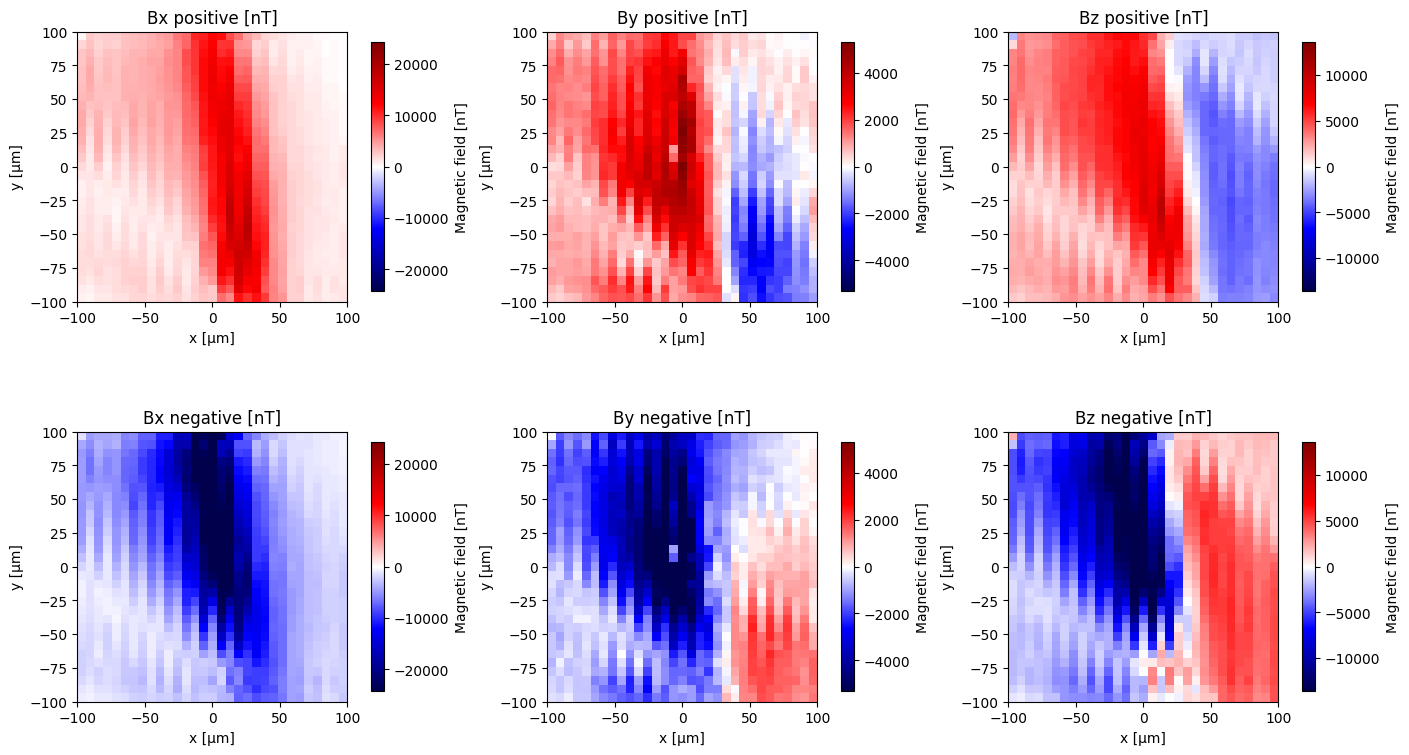

In [63]:
# Plot reconstructed B-field maps
B_pos_maps = [B_pos_nT[i][grid] for i in range(3)]
B_neg_maps = [B_neg_nT[i][grid] for i in range(3)]

component_limits = []

for i in range(3):
    lim = max(
        np.nanpercentile(np.abs(B_pos_maps[i]), 95),
        np.nanpercentile(np.abs(B_neg_maps[i]), 95),
    )

    if lim == 0 or not np.isfinite(lim):
        lim = 1.0

    component_limits.append(lim)

plot_items = [
    ("Bx positive", B_pos_maps[0], component_limits[0]),
    ("By positive", B_pos_maps[1], component_limits[1]),
    ("Bz positive", B_pos_maps[2], component_limits[2]),
    ("Bx negative", B_neg_maps[0], component_limits[0]),
    ("By negative", B_neg_maps[1], component_limits[1]),
    ("Bz negative", B_neg_maps[2], component_limits[2]),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

for ax, (title, data, lim) in zip(axes.ravel(), plot_items):
    im = ax.imshow(
        data,
        extent=EXTENT_UM,
        origin="lower",
        aspect="equal",
        cmap=CMAP_DIVERGING,
        vmin=-lim,
        vmax=lim,
    )

    ax.set_title(f"{title} [nT]")
    ax.set_xlabel("x [µm]")
    ax.set_ylabel("y [µm]")

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Magnetic field [nT]")

plt.show()

In [ ]:
#SAVE
B_odd_nT = 0.5 * (B_pos_nT - B_neg_nT)
B_even_nT = 0.5 * (B_pos_nT + B_neg_nT)

x_values_um = np.linspace(EXTENT_UM[0], EXTENT_UM[1], grid_size)
y_values_um = np.linspace(EXTENT_UM[2], EXTENT_UM[3], grid_size)

rows = []

for row in range(grid_size):
    for col in range(grid_size):
        pixel = int(grid[row, col])

        out = {
            "pixel": pixel,
            "row": row,
            "col": col,
            "x_um": float(x_values_um[col]),
            "y_um": float(y_values_um[row]),

            "OFF_start_s": float(OFF_TIME[0]),
            "OFF_end_s": float(OFF_TIME[1]),
            "OFF_first_frame": int(off_indices[0]),
            "OFF_last_frame": int(off_indices[-1]),

            "POS_time_requested_s": float(POS_TIME),
            "NEG_time_requested_s": float(NEG_TIME),
            "POS_time_actual_s": float(time_s[pos_idx]),
            "NEG_time_actual_s": float(time_s[neg_idx]),
            "POS_frame": int(pos_idx),
            "NEG_frame": int(neg_idx),
        }

        for i, axis in enumerate(AXES_ORDER):
            out[f"dV_pos_{axis}_V"] = float(dV_pos[i, pixel])
            out[f"dV_neg_{axis}_V"] = float(dV_neg[i, pixel])
            out[f"deltaNu_pos_{axis}_MHz"] = float(deltaNu_pos_MHz[i, pixel])
            out[f"deltaNu_neg_{axis}_MHz"] = float(deltaNu_neg_MHz[i, pixel])

        for i, comp in enumerate(B_COMPONENTS):
            out[f"{comp}_pos_nT"] = float(B_pos_nT[i, pixel])
            out[f"{comp}_neg_nT"] = float(B_neg_nT[i, pixel])
            out[f"{comp}_odd_nT"] = float(B_odd_nT[i, pixel])
            out[f"{comp}_even_nT"] = float(B_even_nT[i, pixel])

        rows.append(out)

B_results_df = pd.DataFrame(rows)
B_results_df.to_csv(B_RESULTS_CSV_PATH, index=False)

metadata_df = pd.DataFrame([
    {"key": "coordinate_x", "value": "horizontal image axis; magnet line M1-to-M2"},
    {"key": "coordinate_y", "value": "vertical image axis; approximate wire direction"},
    {"key": "coordinate_z", "value": "optical axis; diamond surface normal"},
    {"key": "grid", "value": "31x31 serpentine grid; same grid used for plotting"},
    {"key": "phase_definition", "value": "OFF interval average; POS and NEG are single frames"},
    {"key": "OFF_TIME_s", "value": str(OFF_TIME)},
    {"key": "POS_TIME_requested_s", "value": POS_TIME},
    {"key": "NEG_TIME_requested_s", "value": NEG_TIME},
    {"key": "POS_TIME_actual_s", "value": float(time_s[pos_idx])},
    {"key": "NEG_TIME_actual_s", "value": float(time_s[neg_idx])},
    {"key": "POS_frame", "value": int(pos_idx)},
    {"key": "NEG_frame", "value": int(neg_idx)},

    {"key": "pulse_amplitude_V", "value": PULSE_AMPLITUDE_V},
    {"key": "pulse_amplitude_mV", "value": PULSE_AMPLITUDE_mV},
    {"key": "artificial_pulse_file", "value": "artificial_pulse_10mV.csv"},
    {"key": "pulse_timing_file", "value": "pulse_timing_10mV.csv"},
    {"key": "pulse_convention", "value": "0 V during OFF; -0.010 V during NEG; +0.010 V during POS"},

    {"key": "B_unit", "value": "nT"},
    {"key": "deltaNu_unit", "value": "MHz"},
    {"key": "dV_unit", "value": "V"},
    {"key": "note", "value": "B components assume corrected lab-frame A_results.csv"},

    {"key": "current_pos_A", "value": 2e-3},
    {"key": "current_neg_A", "value": -2e-3},
    {"key": "current_pos_mA", "value": 2.0},
    {"key": "current_neg_mA", "value": -2.0},
    {"key": "effective_wire_height_um_for_simulation", "value": 20.0},
])

metadata_df.to_csv("B_results_metadata.csv", index=False)

print(f"Saved {B_RESULTS_CSV_PATH}")
print("Saved B_results_metadata.csv")
print("B_results shape:", B_results_df.shape)
display(B_results_df.head())

Saved B_results.csv
Saved B_results_metadata.csv
B_results shape: (961, 43)


,pixel,row,col,x_um,y_um,OFF_start_s,OFF_end_s,OFF_first_frame,OFF_last_frame,POS_time_requested_s,...,Bx_odd_nT,Bx_even_nT,By_pos_nT,By_neg_nT,By_odd_nT,By_even_nT,Bz_pos_nT,Bz_neg_nT,Bz_odd_nT,Bz_even_nT
0,930,0,0,-100.000000,-100.0,0.0,0.05,0,129,0.0627,...,768.305717,-78.902889,545.428593,-322.467117,433.947855,111.480738,1438.798915,-707.985915,1073.392415,365.406500
1,929,0,1,-93.333333,-100.0,0.0,0.05,0,129,0.0627,...,603.254149,-81.547248,460.048292,-375.172839,417.610566,42.437726,1252.943629,-442.099771,847.521700,405.421929
2,868,0,2,-86.666667,-100.0,0.0,0.05,0,129,0.0627,...,1036.426016,-44.324033,637.042241,-200.989737,419.015989,218.026252,1743.018041,-959.321990,1351.170015,391.848026
3,867,0,3,-80.000000,-100.0,0.0,0.05,0,129,0.0627,...,1032.502767,-42.422899,742.977032,-544.401171,643.689101,99.287931,1711.726587,-952.796450,1332.261518,379.465069
4,806,0,4,-73.333333,-100.0,0.0,0.05,0,129,0.0627,...,1378.114306,-13.535066,1058.538880,-539.910169,799.224524,259.314356,1907.558928,-1659.127275,1783.343102,124.215826
